# Project Foundations for Data Science: FoodHub Data Analysis #

### Context ###
The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective: ###
The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.
Data DescriptionThe data contains the different data related to a food order. The detailed data dictionary is given below.

Data Dictionary:
order_id: Unique ID of the order
customer_id: ID of the customer who ordered the food
restaurant_name: Name of the restaurant
cuisine_type: Cuisine ordered by the customer
cost: Cost of the order
day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
rating: Rating given by the customer out of 5
food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

Let us start by importing the required libraries

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd
import warnings

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('foodhub_order.csv')

Understanding the structure of the data

Observations:The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

In [2]:
df.shape
#There are 1898 rows and 9 columns in this dataset. 

(1898, 9)

Observations:There are 1898 rows and 9 columns in this dataset.

Question 2: What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


### Observations: ###

There are 9 columns in this dataset. There are 4 int64 datatypes: order_id, customer_id, food_preparation_time, and delivery_time.
There are 4 objects: restaurant_name, cuisine_type, days_of_the_week, and rating. There is one float64 type: cost_of_the_order.

### Question 3: ### Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [4]:
# We can see that all of the columns have 1898 non-null values in the code above, so we can confirm that there are no null values in the dataset. 
df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

Observations:
We can see that all of the columns have 1898 non-null values in the code above, so we can confirm that there are no null values in the dataset. We can double check this is true by summing the pandas isnull function. We see that all of the null values for each column sum to 0, so there are no null values in this dataset.

Question 4: Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [5]:
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


Observations:Using the describe command, we can see the statistical summary of the dataset. The minumum time taken for food to be prepared is 20 minutes. The average time taken for food to be prepared is 27.371970 minutes.The maximum time taken for food to be prepared is 35 minutes.

Question 5: How many orders are not rated? [1 mark]

In [6]:
#We can count the number of times an order rating is not given
not_given = (df["rating"] == "Not given").value_counts()
print(not_given)

rating
False    1162
True      736
Name: count, dtype: int64


Observations:We can see that the rating is Not given (True) a total of 736 times in the dataset.

Exploratory Data Analysis (EDA)

Univariate Analysis

Question 6: Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [7]:
#1. order_id is an integer, and we know from the data dictionary that it is supposed to be unique for each order.
#We can confirm this by counting the number of unique values and making sure that it's the same as the number of rows.
#We see from the pandas nunique function that there are 1898 unique order_ids, so we can confim that each of these are unique.
df["order_id"].nunique()

1898

In [8]:
#2. customer_id is also an int, and is a unique ID for each customer. These IDs do not necessarily have to be unique if a customer has placed multiple orders
#A groupby will determine the number of unique customers, as well as the describe function to determine the maximum number of orders a customer has placed. 
#We can see that there are 1200 unique customer ids, and the minumum number of orders is 1 (we expect this), and the maximum number of orders a customer has palced is 13. 

#We also see that the average number of orders is: 1.581667 with a standard deviation of 1.090560. 
#From the quartiles, since we know that the min is 1, this means for the first quartile, the lowest 25% of the customers have placed 1 order. 
#The second quartile or the median have placed 1 order, so this means that the lowest 50% of customers have placed 1 order.
#From the third quartile, we know that the top 25% of people have placed 2 orders or above.
customer_count = df.groupby("customer_id").size()
# print(customer_count)
sorted_customer_id = customer_count.sort_values(ascending=False)
print(sorted_customer_id)
sorted_customer_id.describe()

customer_id
52832     13
47440     10
83287      9
250494     8
65009      7
          ..
105903     1
105992     1
106006     1
106324     1
405334     1
Length: 1200, dtype: int64


count    1200.000000
mean        1.581667
std         1.090560
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        13.000000
dtype: float64

In [9]:
#3. restaurant_name is an object, so we are interested in seeing the different names of restaurants and how many orders have been placed at each. 
restaurant_count = df.groupby("restaurant_name").size()
restaurant_count.describe()
sorted_restaurant_count = restaurant_count.sort_values(ascending=False)
print(sorted_restaurant_count)

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
                            ... 
Klong                          1
Kambi Ramen House              1
Il Bambino                     1
Hunan Manor                    1
Lamarca Pasta                  1
Length: 178, dtype: int64


<Axes: xlabel='restaurant_name', ylabel='count'>

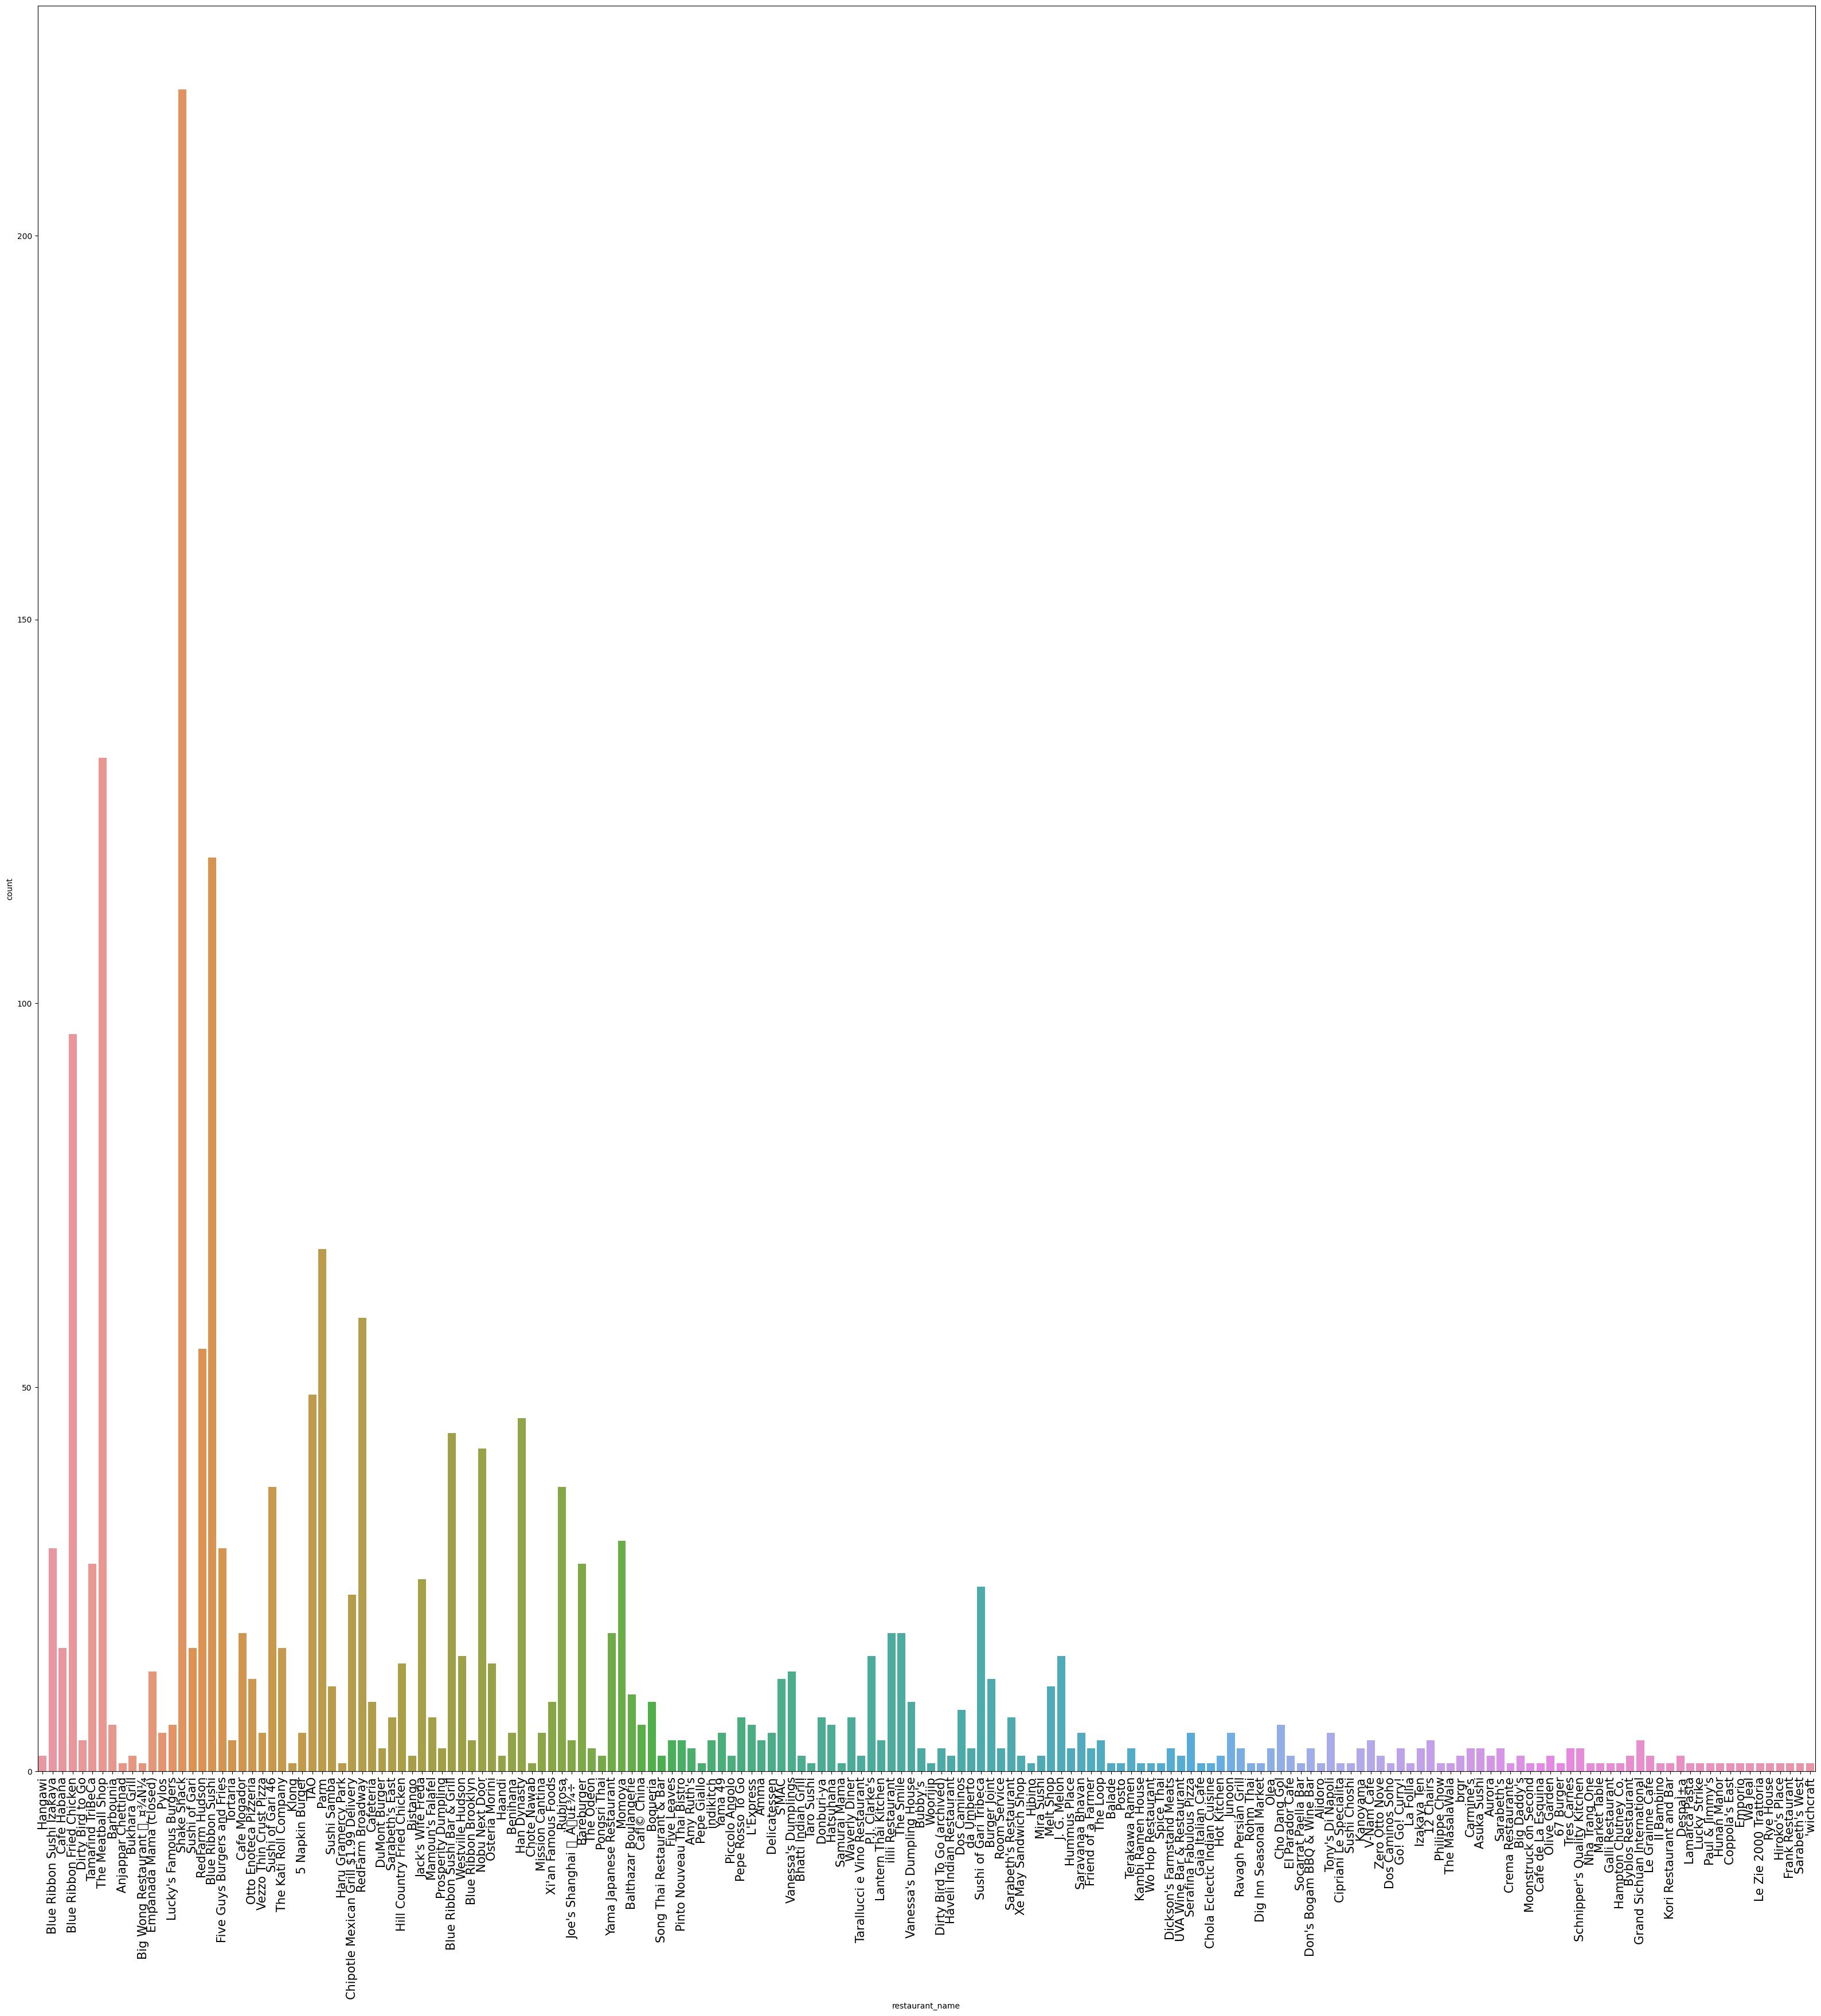

In [10]:
#We can see that there are 178 unique restaurants, where the average number of visits per restaurant is 10.662921 visits.
#Now, we will make a countplot to see the number of times each restaurant is ordered from. 
import warnings
warnings.filterwarnings('ignore', message='Glyph 140')
warnings.filterwarnings('ignore', message='Glyph 142')

plt.figure(figsize=(40,40))
plt.xticks(rotation=90)
plt.tick_params(axis='x', labelsize=15)
plt.rcParams['font.family'] = 'Arial'
sns.countplot(data=df, x="restaurant_name")

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
dtype: int64


<Axes: xlabel='cuisine_type', ylabel='count'>

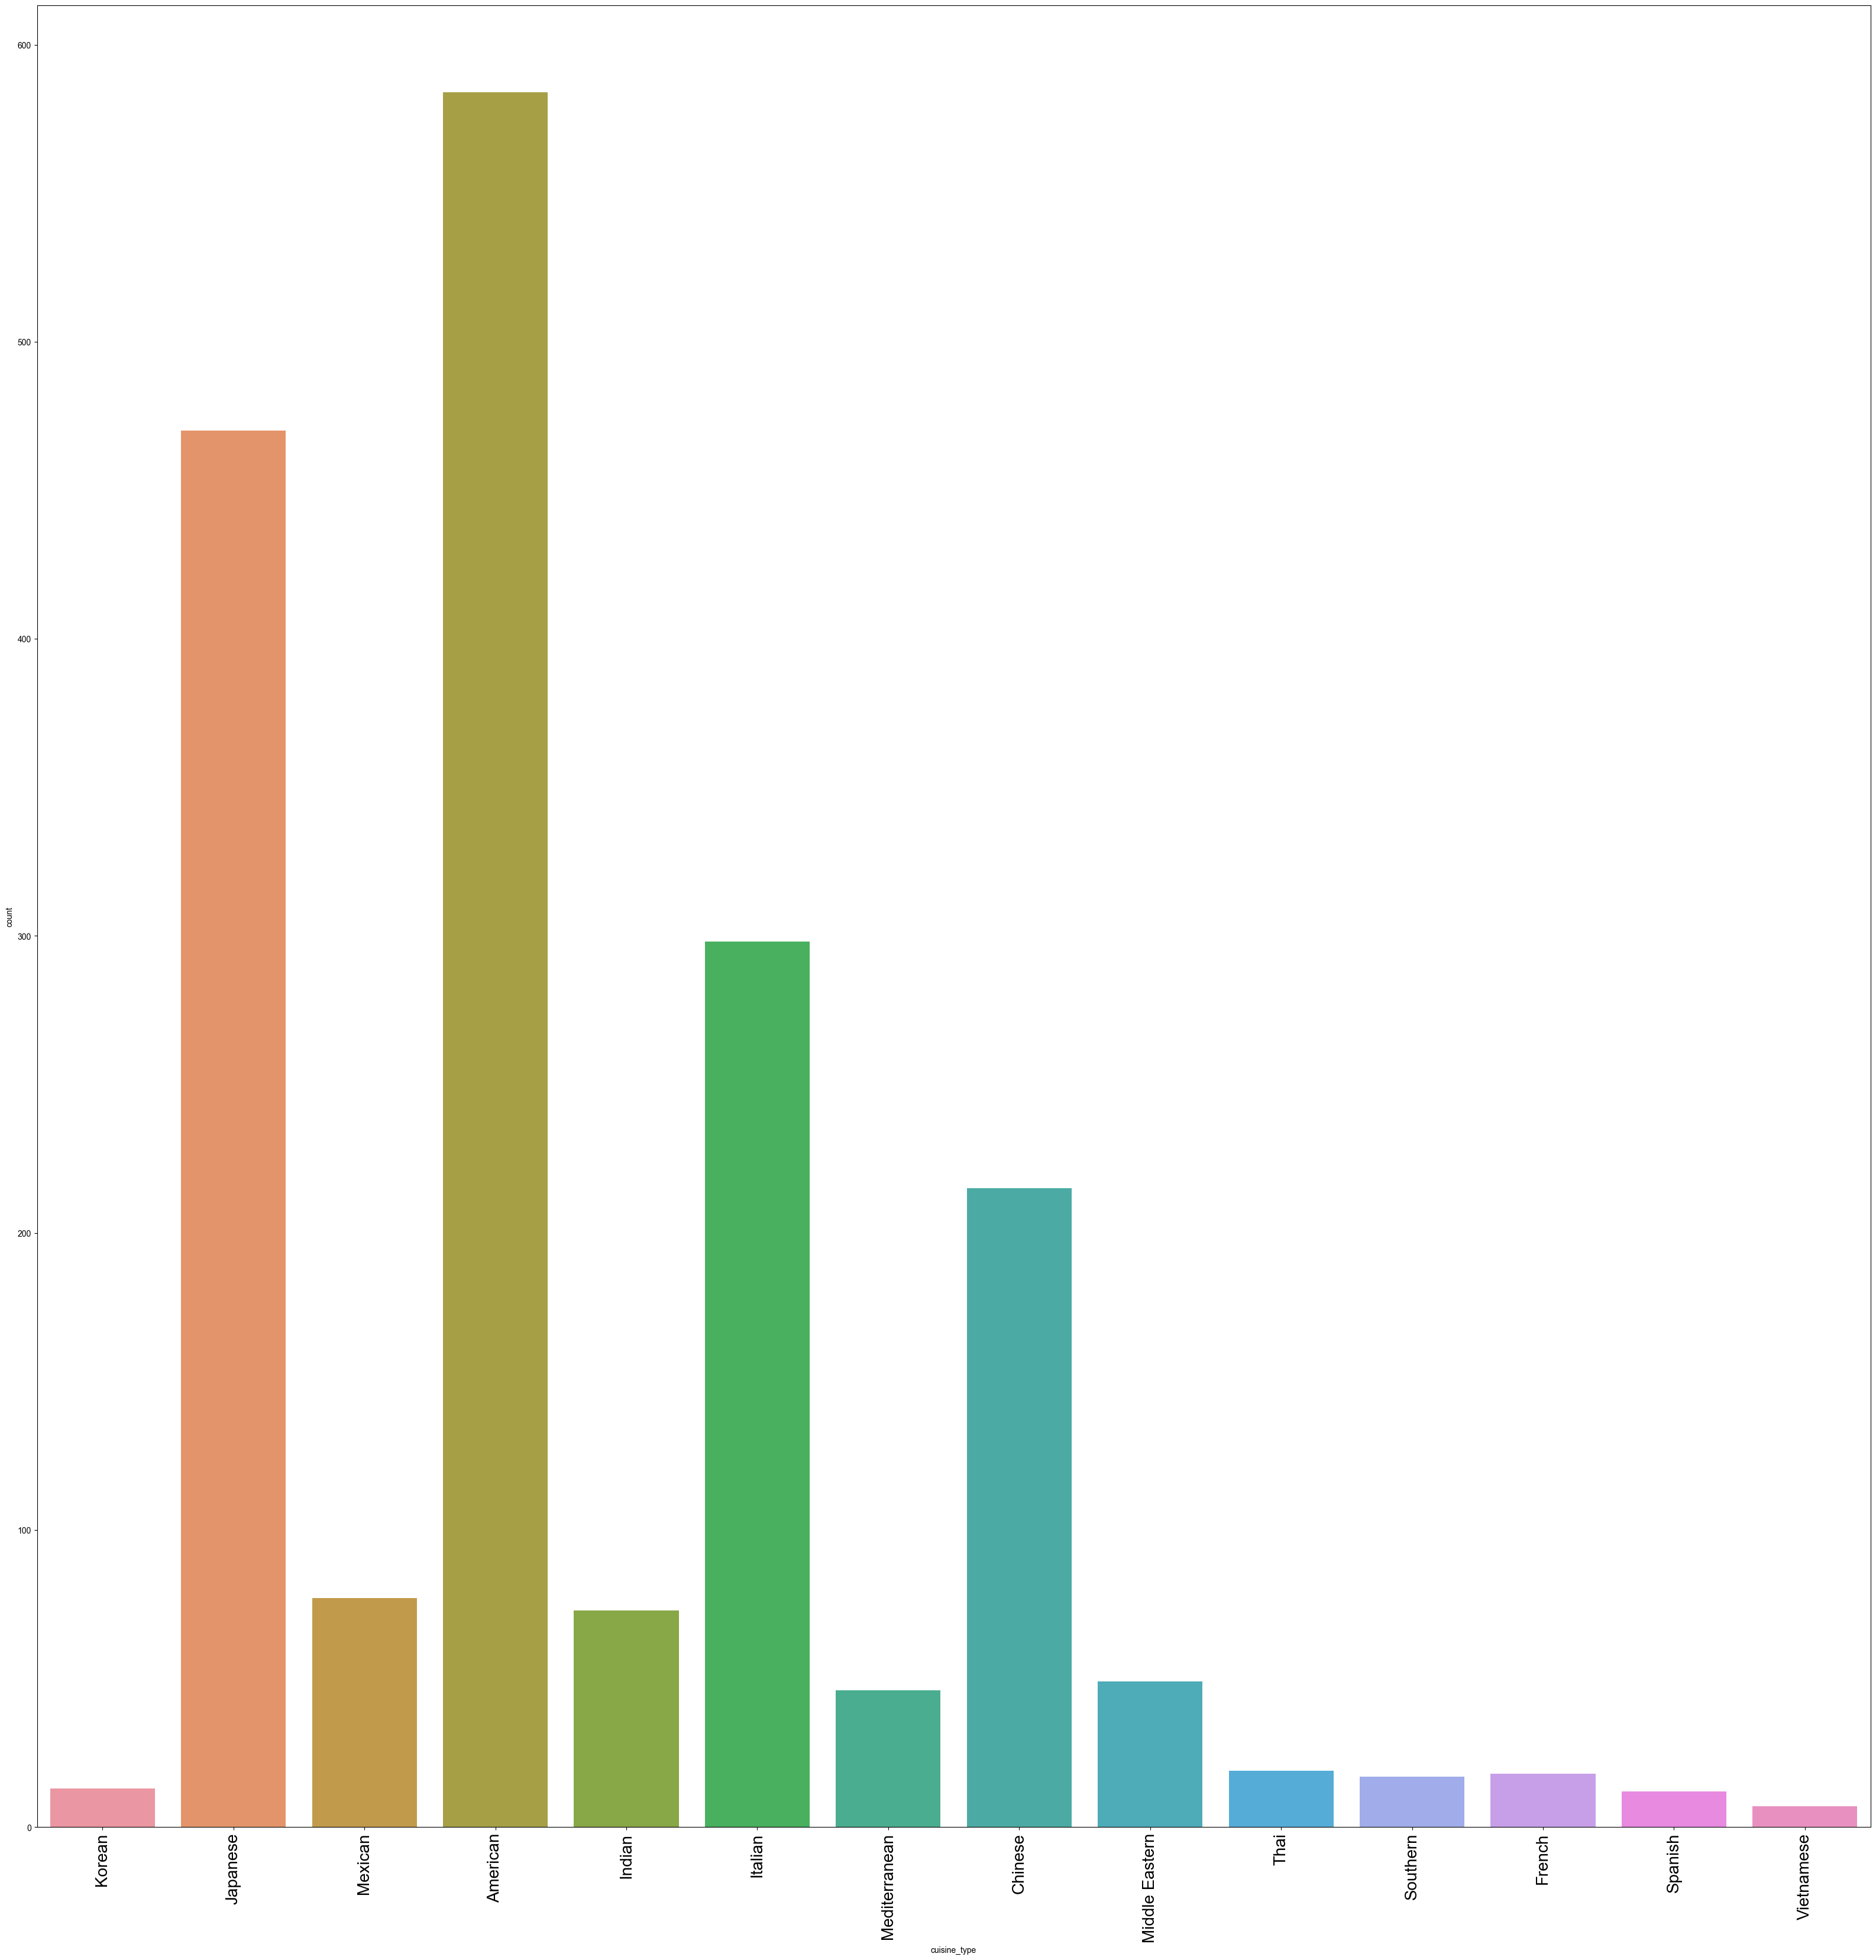

In [11]:
#4 cuisine_type is an object, so we want to see the number of customers that have chosen to purchase each type of food. 
#groups the cuisine_type into counts and takes the size of the matrix
cuisine_type_count = df.groupby("cuisine_type").size()
#sorts in descending order to easily see counts
sorted_count = cuisine_type_count.sort_values(ascending=False)
print(sorted_count)
#plots bar count chart of each cuisine_type
plt.figure(figsize=(40,40))
plt.xticks(rotation=90)
plt.tick_params(axis='x', labelsize=20)
sns.countplot(data=df, x="cuisine_type")
#From grouping the cuisine types, we see that there are 14 types of cuisine options available on foodhub. 
#The top 3 most popular types are: American, Japanese, and Italian. Viatnemese has the least number of orders with 7. 

In [12]:
#5 cost_of_order is an integer, so we can perform numerical analysis on it. I am curious of the mean and median of this column, along with the overall spread. 
#two good charts to look at here are a box plot and a histogram. First we can look at the descriptive statistics of cost_of_order.
order_amount = df["cost_of_the_order"]
#we see here that the max order amount is 35.41, and the minimum is 4.46. The mean is about 16.5.
order_amount.describe()

count    1898.000000
mean       16.498851
std         7.483812
min         4.470000
25%        12.080000
50%        14.140000
75%        22.297500
max        35.410000
Name: cost_of_the_order, dtype: float64

<Axes: xlabel='cost_of_the_order'>

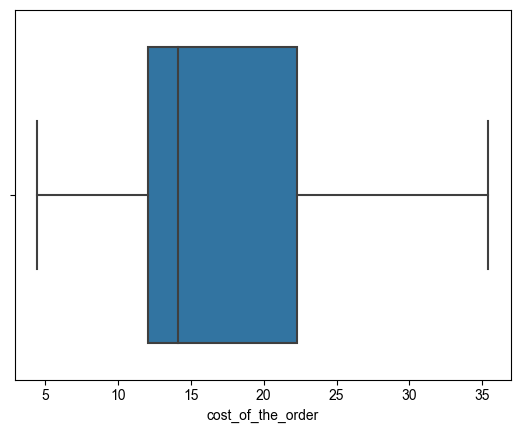

In [13]:
#next we will make a box plot of order cost to see the distribtuion. 
sns.boxplot(data=df, x="cost_of_the_order")
#from the boxplot, we can see that the orders are skewed right, which indicates that a majority of the data lies to the left or is less than the mean.
#we can confirm this by seeing that the mean is less than the median.
#There are no outliers.

<Axes: xlabel='cost_of_the_order', ylabel='Count'>

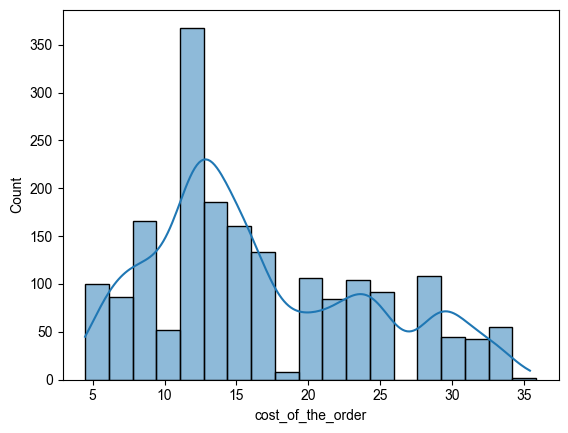

In [14]:
#We are also interested in the spread of the data, so we can look at a histogram.
cost_of_the_order = df['cost_of_the_order'].values
def bin_width_calc(cost_of_the_order):
    IQR = np.percentile(cost_of_the_order, 75) - np.percentile(cost_of_the_order, 25)
    n = len(cost_of_the_order)
    bin_width = 2 * IQR / n**(1/3)
    return bin_width
    
bin_width_IQR = bin_width_calc(cost_of_the_order)
#prints binwidth
#bins = range = (max-min) /binwidth
sns.histplot(data=df, x="cost_of_the_order", binwidth=1.650476098152262, bins=(30.94/1.650476098152262), kde=True)
#From the histogram, we can see that a majority of orders are between 11 and 16 dollars. We can also see from the density curve that the data is right skewed, 
#as we saw from the boxplot.

day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64
71.18018967334035
28.819810326659645


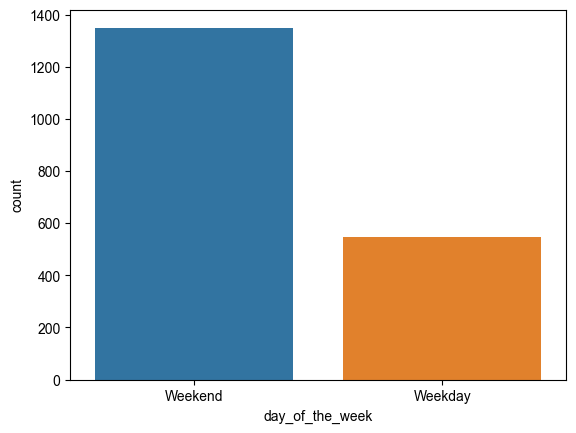

In [15]:
#6 day_of_the_week: Since this is an object with boolean values "weekday/weekend", we can count the number of each and make a bar chart to see the amount of orders happening for each

weekday_counts = df["day_of_the_week"].value_counts()
print(weekday_counts)
sns.countplot(data=df, x="day_of_the_week")
#We can see that there are 1351 orders on the weekend, and 547 orders placed on the weekdays in this dataset. 
#From this, we can calculate the percentage of each; where 71.18% of orders are placed on the weekends and 28.82% are placed on the weekdays.
weekday_percent = weekday_counts.iloc[0] / (weekday_counts.iloc[0] + weekday_counts.iloc[1]) 
weekend_percent = (1 - weekday_percent) * 100
print(weekday_percent*100)
print(weekend_percent)

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64
Percentage of ratings Not Given: 38.77766069546891
Percentage of 5/5 Rating: 30.979978925184405
Percentage of 4/5 Rating: 20.337197049525816
Percentage of 3/5 Rating: 9.905163329820864


<Axes: xlabel='rating', ylabel='count'>

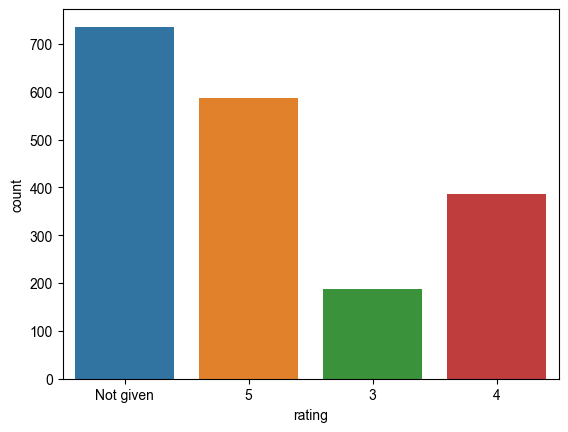

In [16]:
#7 rating: Since this is an object with values of 3,4,5 and Not Given, we can investigate the percentages of each rating and make a countplot of the ratings.

rating_counts = df["rating"].value_counts()
print(rating_counts)

rating_percent_not_given = rating_counts.iloc[0] / (rating_counts.iloc[0] + rating_counts.iloc[1] + rating_counts.iloc[2] + rating_counts.iloc[3] ) 
rating_percent_5 = rating_counts.iloc[1] / (rating_counts.iloc[0] + rating_counts.iloc[1] + rating_counts.iloc[2] + rating_counts.iloc[3] ) 
rating_percent_4 = rating_counts.iloc[2] / (rating_counts.iloc[0] + rating_counts.iloc[1] + rating_counts.iloc[2] + rating_counts.iloc[3] ) 
rating_percent_3 = rating_counts.iloc[3] / (rating_counts.iloc[0] + rating_counts.iloc[1] + rating_counts.iloc[2] + rating_counts.iloc[3] ) 
print("Percentage of ratings Not Given:", rating_percent_not_given*100)
print("Percentage of 5/5 Rating:", rating_percent_5*100)
print("Percentage of 4/5 Rating:", rating_percent_4*100)
print("Percentage of 3/5 Rating:", rating_percent_3*100)

sns.countplot(data=df, x="rating")

In [17]:
#8 food_preparation_time is an integer, so we can look at the descirptive statistics and make a boxplot of the data. 
food_preparation_time = df["food_preparation_time"]
food_preparation_time.describe()
#We can see that the max amount of time to prepare is 35 mins, the minimum is 20 minutes, and the data is fairly evenly distributed since the mean (27.37) and median (27) are very close together.

count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64

<Axes: xlabel='food_preparation_time'>

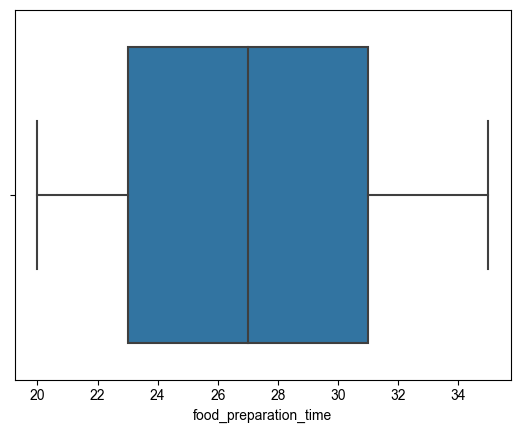

In [18]:
sns.boxplot(data=df, x="food_preparation_time")
#we can confirm from the boxplot that the data is evenly distributed. There are no outliers. 

In [19]:
#9 delivery_time is an integer, so we can look at the descirptive statistics and make a boxplot of the data. 
delivery_time = df["delivery_time"]
delivery_time.describe()
#We can see that the max amount of time to deliver is 33 mins, the minimum is 15 minutes, and the data is slightly left skewed since the mean is less than the median.

count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64

<Axes: xlabel='delivery_time'>

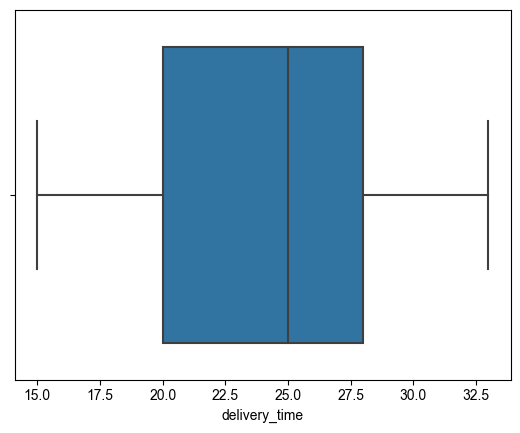

In [20]:
sns.boxplot(data=df, x="delivery_time")
#we can see that the delivery time is slightly left skewed, since a majority of the data falls to the right of the mean. 

Question 7: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [21]:
top_5_restaurants = df["restaurant_name"].value_counts()
top_5_restaurants.head(5)

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

Observations:By using the value_counts function, we can count how many times each restaurant is ordered from in our dataset to determine the top 5 restaurants and print the top 5 counts.

Question 8: Which is the most popular cuisine on weekends? [1 mark]

In [22]:
weekend_only = df.loc[df["day_of_the_week"] == "Weekend"]
counts_for_weekends = weekend_only['cuisine_type'].value_counts()
print(counts_for_weekends)

cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Mediterranean      32
Middle Eastern     32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64


Question 9: What percentage of the orders cost more than 20 dollars? [2 marks]

In [23]:
#By using the loc function and setting a condition that the order time is > 20, we can count the number of times that orders are over 20$.
orders_over_20 = df.loc[df["cost_of_the_order"] > 20]
orders_over_20.value_counts()
percentage_over_20 = len(orders_over_20)/len(df)
print("Percentage of orders above 20 dollars:", percentage_over_20 * 100)

Percentage of orders above 20 dollars: 29.24130663856691


Observations:By using the loc function and setting a condition that the order time is > 20, we can count the number of times that orders are over 20 dollars.
Next, we can caluclate the percentage by dividing the number of times orders are over 20 dollars by the length of all enteries in the dataframe and multiplying it by 100. We find that 29.24% of orders are over 20 dollars

Question 10: What is the mean order delivery time? [1 mark]

In [24]:
#We can use the mean or the describe function to calculate the average delivery time.
df["delivery_time"].mean()
df["delivery_time"].describe()

count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64

Observations:
By taking the mean of delivery_time, we find that it results in 24.161749. We can also confirm this by using the describe function on delivery time.

Question 11: The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [25]:
#groups the customers by number of times customer_id is entered, prints the top 3 customers.
top_3_customers = df["customer_id"].value_counts()
top_3_customers.head(3)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

Observations:We can count the number of times each customer id is entered to create a vector with all the times each customer orders.

## Multivariate Analysis ##

Question 12: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]

In [26]:
#After looking at correlations between the numerical values of the dataset, there is no clear indication that any of these are highly correlated.
#We see a slightly higher correlation between rating of the order, cost of the order, and cost of the order and food preparation time
#However, these are not highly significant since they have values of 0.033983 for cost_of_the_order and rating_without_not_given and 
#0.041527 for cost_of_the_order and food_preparation_time. This means that for every dollar the order cost goes up, the rating will increase by 0.033983.
#similaraly, for every additional dollar the order costs, the time of preparation will increase by 0.041527 minutes.
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
df['rating_without_not_given'] = df['rating'].replace('Not given', np.nan)
df['rating_without_not_given'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_without_not_given'] = df['rating_without_not_given'].astype('Int64')
df[["rating_without_not_given", "delivery_time","cost_of_the_order","food_preparation_time"]].corr()
# sns.heatmap(data=df[["rating_without_not_given", "delivery_time","cost_of_the_order","food_preparation_time"]].corr())


,rating_without_not_given,delivery_time,cost_of_the_order,food_preparation_time
rating_without_not_given,1.000000,-0.009804,0.033983,-0.006083
delivery_time,-0.009804,1.000000,-0.029949,0.011094
cost_of_the_order,0.033983,-0.029949,1.000000,0.041527
food_preparation_time,-0.006083,0.011094,0.041527,1.000000


<Axes: xlabel='day_of_the_week', ylabel='total_time'>

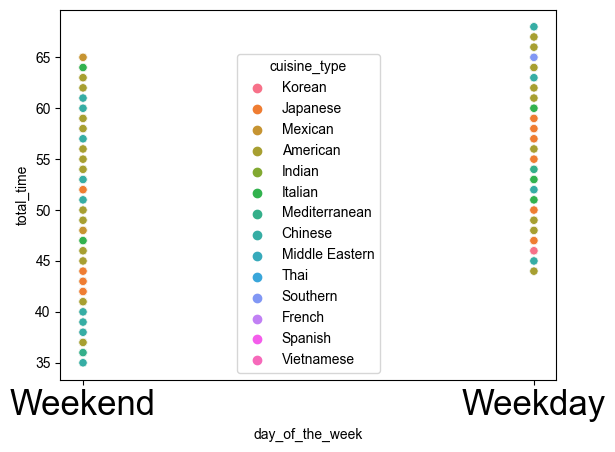

In [27]:
#Next, we can use plots to identify any relationship between the numerical and categorical variables. 
#first, we're looking at the relationship between rating and the total time it takes to recieve an order.
#We can see here that the total time for orders on the weekdays has a distribution of taking longer than on the weekends. From setting the hue to cuisine_type, 
#we can see that this is not caused by a particular cuisine type.
plt.tick_params(axis='x', labelsize=25)
sns.scatterplot(data=df, x="day_of_the_week", y="total_time", hue="cuisine_type")


<Axes: xlabel='day_of_the_week', ylabel='total_time'>

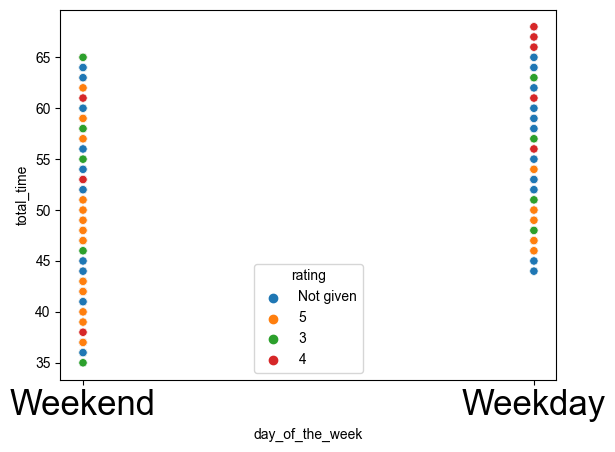

In [28]:
#Now, we want to look at the relationship between day of the week, total time that it takes to recieve orders, and the rating.
#We can see here that a majority of the 5/5 ratings come from a lower total time of delivery. Specifically, for weekdays,
#there are no 5/5 ratings for orders that take a total time of above 55 minutes.
plt.tick_params(axis='x', labelsize=25)
sns.scatterplot(data=df, x="day_of_the_week", y="total_time", hue="rating")


<Axes: xlabel='day_of_the_week', ylabel='delivery_time'>

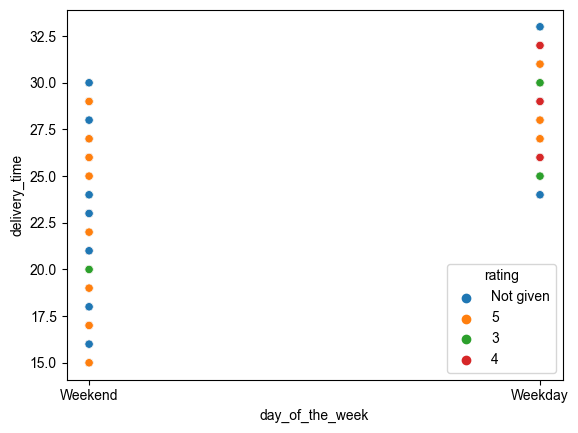

In [29]:
#We can look at the same plot for delivery_time and food_preparation_time to see if there is a clear indicator on what's causing this.
sns.scatterplot(data=df, x="day_of_the_week", y="delivery_time", hue="rating")
#This plot shows a more intense distribtuion difference between delivery_time and day_of_the week, which indicates that the time taken to deliver the order
#is the underlying cause of the total time being different depending on day of the week.


<Axes: xlabel='day_of_the_week', ylabel='food_preparation_time'>

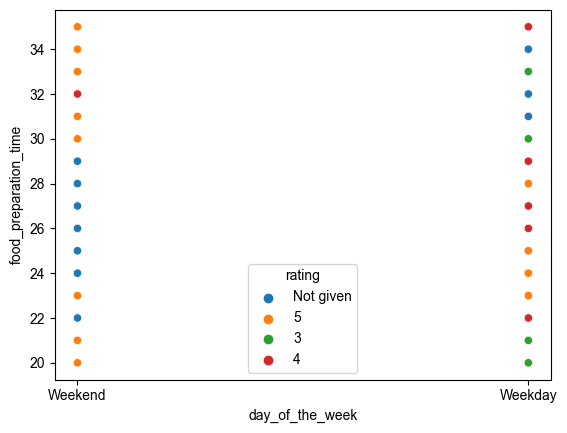

In [30]:
sns.scatterplot(data=df, x="day_of_the_week", y="food_preparation_time", hue="rating")
#We can see below that there is not a significant difference between food preparation time on the weekdays vs. weekends. Similaraly, we can see that 
#there are lots of 5/5 ratings for the longest food preparation times on the weekends, so we can determine that food preparation time is most likely not impacting
#the rating. Additionally, we already know that delivery time is impacting total time more significantly on the weekdays, and there are 3/5 ratings on the weekdays 
#that have the lowest food preparation time, so this is most likely not causing the poor ratings. 


In [31]:
print(df['restaurant_name'].dtype)
print(df['restaurant_name'].head())

object
0                      Hangawi
1    Blue Ribbon Sushi Izakaya
2                  Cafe Habana
3    Blue Ribbon Fried Chicken
4             Dirty Bird to Go
Name: restaurant_name, dtype: object


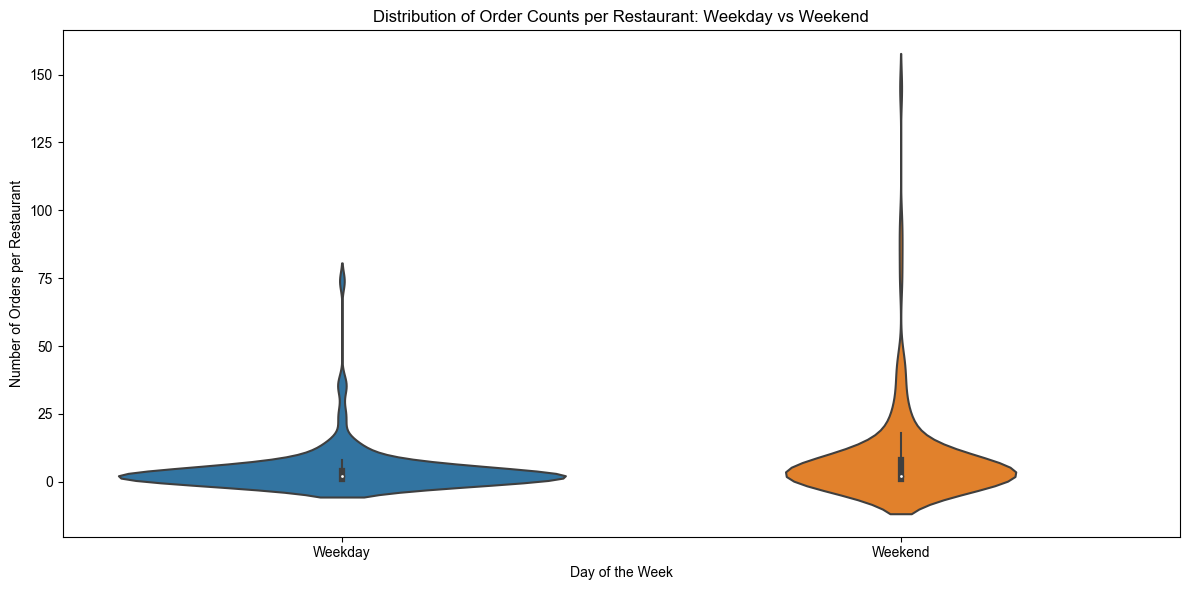

In [32]:
#next, we are interested in the difference of distributions between restaurant names and the days of the week. Since there are so many restaurants, the best
#way to look at this large section of data is with a violin plot so we can easily compare the distributions. The similar shapes indicate there is a minimal difference
#of restaurant distributions between the weekday and weekends, however it appears that there's a longer tail during the weekdays which indicates that there's a
#wider variety of restaurants being ordered from during the week.
# Top N restaurants only
import warnings
warnings.filterwarnings('ignore')

# Count orders per restaurant per day
order_counts = df.groupby(['restaurant_name', 'day_of_the_week']).size().reset_index(name='order_count')

plt.figure(figsize=(12, 6))
sns.violinplot(data=order_counts, x="day_of_the_week", y="order_count")
plt.title("Distribution of Order Counts per Restaurant: Weekday vs Weekend")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Orders per Restaurant")
plt.tight_layout()
plt.show()

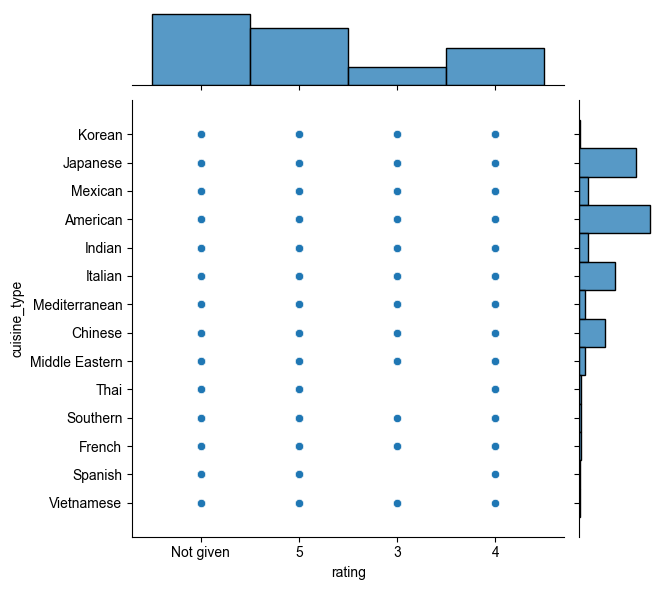

In [33]:
#next, we can identify the relationship between type of food and the ratings of the restaurants using a joint plot and a strip plot.
sns.jointplot(data=df, x="rating", y="cuisine_type")
#From the joint plot, we can see there is some relationship between rating and food type. 
#More notably, from this view we can see that there are a couple restaurants that haven't received a 3/5 rating: Thai and Spanish.
#All other cuisine types have received every rating type.
#The histogram on the cuisine type side shows a right skew, which indicates that the most ordered from restaurants are at the top of the chart. 


<Axes: xlabel='rating', ylabel='cuisine_type'>

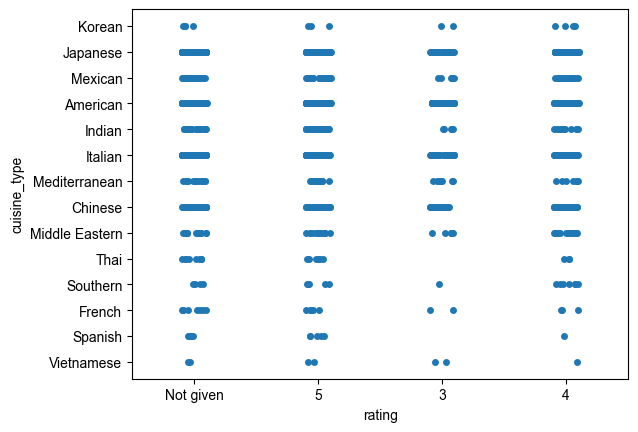

In [34]:
sns.stripplot(data=df, x="rating", y="cuisine_type")
#This plot shows a strip plot between cuisine type and rating. Here, we can see all the ratings for every cuisine type. 
#This view is good for seeing the density of ratings for each cusine type. We can see that for some cuisine types there are less points in the 
#3/5 rating graph. For example, Mediterranean and Indian cuisine has a lower density of 3/5 ratings than it has for 5/5, 4/5, and not given.
#For Italian and American, we can see there is a wider spread of ratings, since all the rating points are filled in. 


<Axes: xlabel='day_of_the_week', ylabel='cuisine_type'>

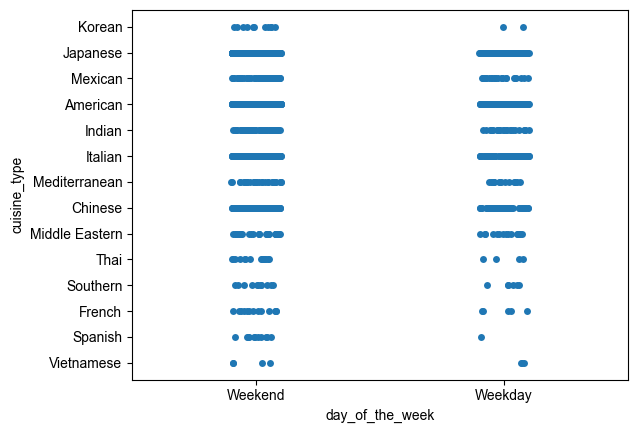

In [35]:
sns.stripplot(data=df, x="day_of_the_week", y="cuisine_type")
#This strip plot shows the relationship between day of the weeek and cuisine type ordered. 
#This figure shows that there are some restaurants that are more likely to be ordered on the weekend vs. weekdays, such as: Mediterranean, 
#Korean, and Thai. For American, Chinese, and Japanese food types, we see that the density is similar for the weekend and the weekdays.


<Axes: xlabel='delivery_time', ylabel='cuisine_type'>

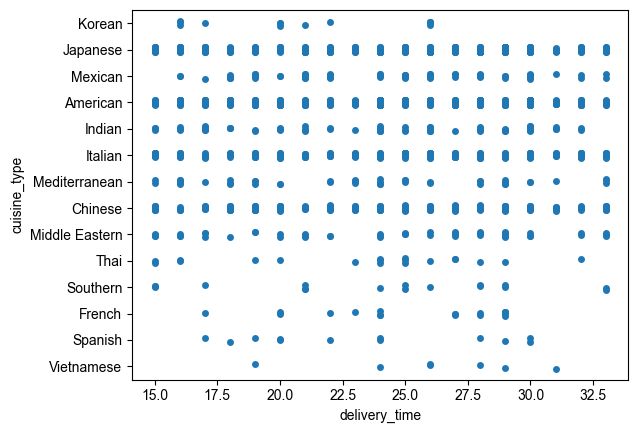

In [36]:
sns.stripplot(data=df, x="delivery_time", y="cuisine_type")
#This plot shows delivery time for each cusine type. We can see here that some restaurants take longer to deliver than other restaurants, while some 
#types have a wide range of how long delivery takes. 


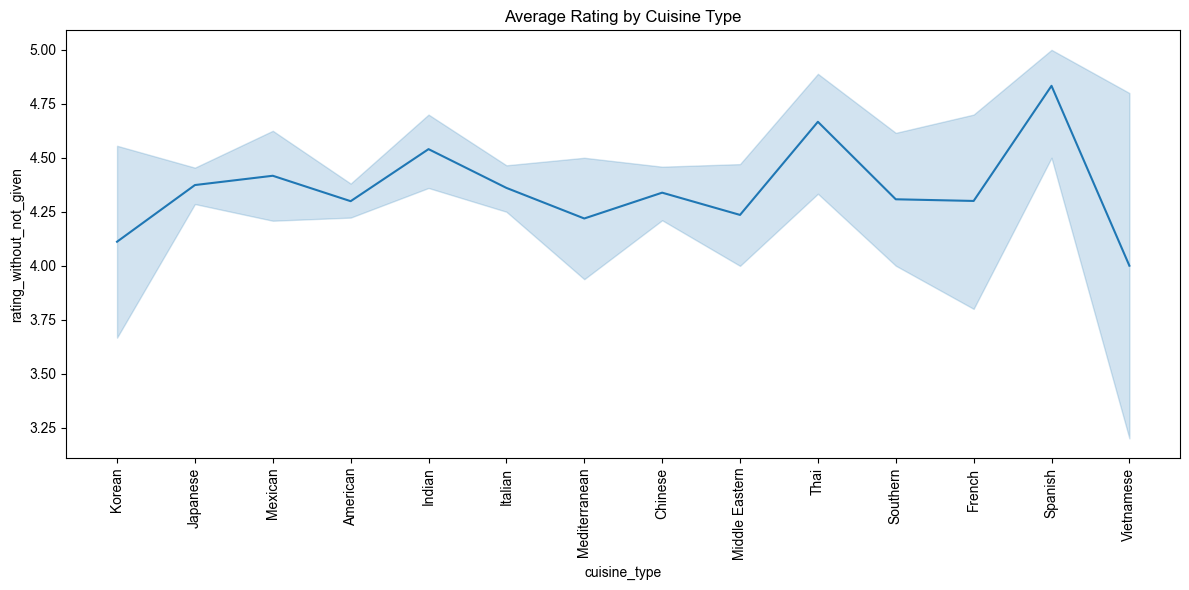

In [37]:
#transitions rating into a numerical value and marks "not given" as null values.
# Convert rating, coercing 'Not given' to NaN
df['rating_without_not_given'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_without_not_given'] = df['rating_without_not_given'].astype('float64')

plt.figure(figsize=(12, 6))
plt.xticks(rotation=90)
sns.lineplot(data=df, x="cuisine_type", y="rating_without_not_given")
plt.title("Average Rating by Cuisine Type")
plt.tight_layout()
plt.show()

In [38]:
df['rating_without_not_given'] = df['rating'].replace('Not given', np.nan)
df['rating_without_not_given'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_without_not_given'] = df['rating_without_not_given'].astype('Int64')
requirements = df.groupby('restaurant_name').agg(
    rating_count=('rating_without_not_given', 'size'),
    average_rating=('rating_without_not_given', 'mean')
)
qualified_restaurants = requirements[(requirements['rating_count'] > 50) & (requirements['average_rating'] > 4)]
print(qualified_restaurants)


                           rating_count  average_rating
restaurant_name                                        
Blue Ribbon Fried Chicken            96        4.328125
Blue Ribbon Sushi                   119        4.219178
Parm                                 68        4.128205
RedFarm Broadway                     59        4.243902
RedFarm Hudson                       55        4.176471
Shake Shack                         219        4.278195
The Meatball Shop                   132        4.511905


Observations:This logic first converts the "rating" column to numeric values which gives blanks for the "Not Given" values, since this will mess up the averages. Next, it groups by restaurant name to give how many times each restaurant is ordered from, and creates the average rating for each restaurant. Then, we are able to create a conditional argument that requires the rating_count to be > 50 and the average rating to be greater than 4. The qualified restaurants are then printed.

Question 14: The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [39]:
def revenue(cost_of_the_order):
    if cost_of_the_order > 20:
        return cost_of_the_order * 0.25
    elif cost_of_the_order > 5:
        return cost_of_the_order * 0.15
    else:
        return 0

df['revenue'] = df['cost_of_the_order'].apply(revenue)
total_revenue = df['revenue'].sum()
print(total_revenue)


6166.303


Observations:By creating a function for revenue and taking the cost_of_the_order variable, we can create an if/elif/else function that will give 25% return on orders greater than 20$ by setting it as the first (if) condition. Next, if this condition is not satisified the function will go down to the elif clause, which will give a 15% return on orders between 5 and 20 (since if they are greater than 20, they will be getting 25% and will be marked true by the "if" clause. Next, we will give every other order a 0% return by using the else clause. Then, we can apply the function to a "revenue" column and print the total revenue which is the sum of this column.

Question 15: The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [40]:
# Add the order time and delviery time together
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

greater_than_60 = df['total_time'] > 60
count_greater_than_60 = greater_than_60.sum()
print(count_greater_than_60)
#There are 200 orders that take more than 60 minutes of total time to be prepared and delivered.

200


## Observations: ##
First, we create a total_time column in our dataframe which is the food preparation time and the delivery time added together. Next, we can set a condition for when the total_time is greater than 60 and count the number of times this occurs. We find that a total of 200 orders have greater than 60 minutes of total time to get to the customer.

Question 16: The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [41]:
average_delivery_time = df.groupby('day_of_the_week')['delivery_time'].mean()
print(average_delivery_time)

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


### Observations: ###
To get the average time of delivery on the weekdays and weekends, we can group by "day_of_the_week", and then calculate the mean depending on the two values of the day_of_the_week column (weekday/weekend). Next, we can print the average delivery time which is 28.34 for the weekdays and 22.48 for the weekends. Therefore, the average delivery time is longer on weekdays than on the weekends.

### Conclusion and Recommendations ###

Question 17: What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

Conclusions:
From our FoodHub analysis, we have found insight on variables influencing particular outcomes in the dataset. Particularly, we have found that the density of restaurants that are ordered from are concentrated into a small amount of restaurants, with many restaurants receiving only a few orders.
We have found that the highest density of ratings are Not Given, which indicates that there is no incentive for customers to provide feedback.
Looking at the descriptive statistics of customer_id, we can see that a majority of our users are not repeat users.

Recommendations:
- Give some type of incentive for customer ratings since the highest concentration of ratings are "Not Given"
- Give some type of promotion on the weekdays to increase customer orders
- Improve delivery time, particularly on weekends which has a direct relationship to lower ratings.
- Since there are some restaurants that have been ordered from so infrequently, it could help efficiency to cut down on the number of restaurants offered, especially on the weekdays when there are fewer orders to streamline delivery.
- Give customers incentive to increase order cost to receive higher revenue.
- Give promotional option to increase incentive for customers to order more than once.